In [1]:
import seaborn as sns
import pandas as pd
import scipy.stats as stats

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Show first 5 rows
print(df.head())

# Basic information about dataset
print(df.info())

# Statistical summary
print(df.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [2]:

# Drop missing values in 'age', 'class', and 'sex'
df_clean = df.dropna(subset=['age', 'class', 'sex'])

# Check cleaned dataset
print(df_clean.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [4]:
# Group survival rates by gender

male_survival = df_clean[df_clean['sex'] == 'male']['survived']
female_survival = df_clean[df_clean['sex'] == 'female']['survived']

print(male_survival.head())
print(female_survival.head())

0     0
4     0
6     0
7     0
12    0
Name: survived, dtype: int64
1    1
2    1
3    1
8    1
9    1
Name: survived, dtype: int64


In [5]:
# One-Way ANOVA (Gender vs Survival)

# Compare survival rates between male and female
anova_gender = stats.f_oneway(male_survival, female_survival)

print("ANOVA result (Gender vs Survival):", anova_gender)

ANOVA result (Gender vs Survival): F_onewayResult(statistic=291.2874851899497, pvalue=5.224709926801951e-55)


In [8]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Example: load titanic dataset
import seaborn as sns
df = sns.load_dataset("titanic")

df_clean = df.dropna(subset=["survived","sex","class"])

model = ols('survived ~ C(sex) + C(Q("class"))', data=df_clean).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                   sum_sq     df           F        PR(>F)
C(sex)          53.165350    1.0  353.962098  1.050181e-66
C(Q("class"))   15.286098    2.0   50.885579  1.199893e-21
Residual       133.228010  887.0         NaN           NaN


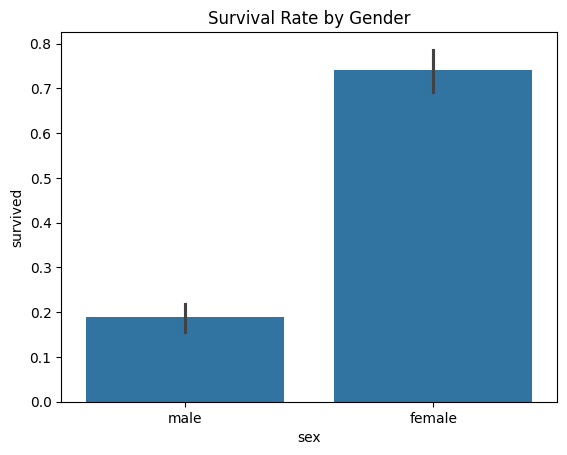

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot: survival rate by gender
sns.barplot(x="sex", y="survived", data=df_clean)

plt.title("Survival Rate by Gender")
plt.show()

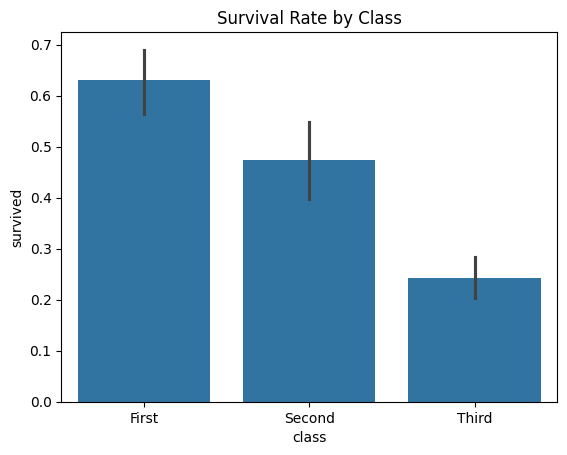

In [10]:
# Bar plot: survival rate by class

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x="class", y="survived", data=df_clean)

plt.title("Survival Rate by Class")
plt.show()

In [2]:
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
# Load Titanic dataset
df = sns.load_dataset("titanic").dropna(subset=['sex', 'class', 'survived'])

# View first rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [7]:
import pandas as pd
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Remove missing values
df = df.dropna(subset=["survived","sex","class"])

# ANOVA model
model = ols('survived ~ C(sex) * C(Q("class"))', data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                          sum_sq     df           F        PR(>F)
C(sex)                 53.165350    1.0  368.191786  6.962809e-69
C(Q("class"))          15.286098    2.0   52.931238  1.934085e-22
C(sex):C(Q("class"))    5.437720    2.0   18.829215  9.812394e-09
Residual              127.790290  885.0         NaN           NaN


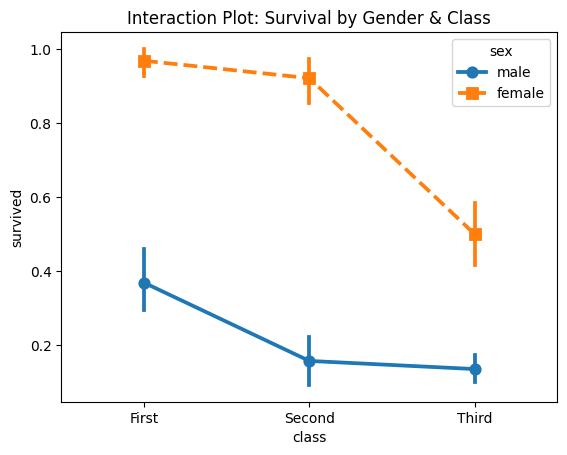

In [8]:
# Visualizing Interaction Effects

import matplotlib.pyplot as plt
import seaborn as sns

sns.pointplot(
    x="class",
    y="survived",
    hue="sex",
    data=df,
    markers=["o", "s"],
    linestyles=["-", "--"]
)

plt.title("Interaction Plot: Survival by Gender & Class")
plt.show()

c:\Users\AMIT PAUL\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


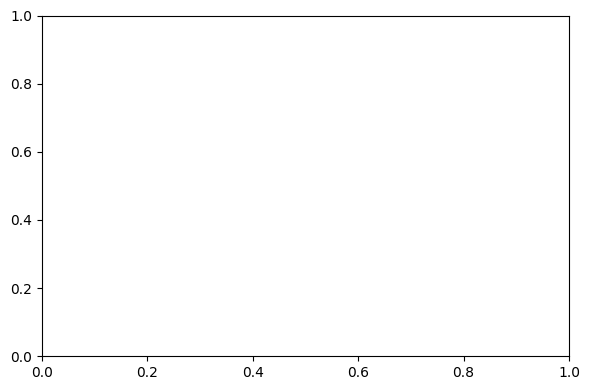

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

# Load dataset
df = sns.load_dataset("titanic").dropna(subset=['sex','class','survived'])

# Create figure
fig, ax = plt.subplots(figsize=(6,4))

def animate(i):
    ax.clear()

    # Random sample each frame
    sample_data = df.sample(frac=0.6)

    sns.barplot(
        x="class",
        y="survived",
        hue="sex",
        data=sample_data,
        palette="Set2",
        ax=ax
    )

    ax.set_ylim(0,1)
    ax.set_title(f"Animated Survival Rates (Frame {i})")
    ax.set_ylabel("Survival Rate")
    ax.set_xlabel("Passenger Class")

# Create animation
ani = animation.FuncAnimation(fig, animate, frames=15, interval=1000)

plt.tight_layout()
plt.show()

                       sum_sq     df         F    PR(>F)
C(sex)              43.857109    1.0  1.187172  0.276994
C(smoker)            8.718644    1.0  0.236006  0.627549
C(sex):C(smoker)   144.779583    1.0  3.919051  0.048884
Residual          8866.202701  240.0       NaN       NaN


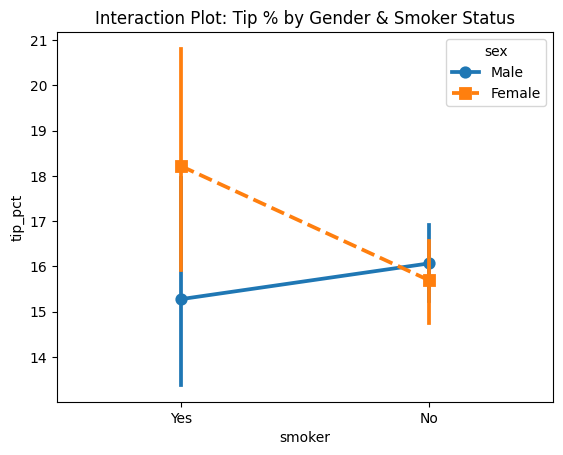

In [14]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

# Load dataset
tips = sns.load_dataset("tips")

# Calculate tip percentage
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100

# Two-way ANOVA: tip percentage ~ gender + smoker
model2 = ols('tip_pct ~ C(sex) * C(smoker)', data=tips).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)

print(anova_table2)

# Interaction plot
sns.pointplot(
    x="smoker",
    y="tip_pct",
    hue="sex",
    data=tips,
    markers=["o", "s"],
    linestyles=["-", "--"]
)

plt.title("Interaction Plot: Tip % by Gender & Smoker Status")
plt.show()